In [1]:
import h5py
import numpy as np
import meshio

import matplotlib.pyplot as plt

from MeshManager import MeshManager


#Set fonts
from matplotlib import rc, rcParams, cm
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})

In [2]:
# Plotting function
def PlotLine(y = 2*56.25/25.4, x = 1.5*56.25/25.4, dpi=100):
    fig, ax = plt.subplots(figsize=(y, x), dpi=dpi, tight_layout=True)
    return ax

In [3]:
# Element name
elementName = "quad"  		# meshio compatible element name
mesh = MeshManager("../CT.msh", elementName)

Reading mesh: CT.msh...

Mesh consistency verified: All domain elements are <quad>.

PHIMATS MESH INITIATION
Detected 1 Material Sets. Follow this order in your Input Data:
  [Index 1] -> Physical Group: 'CT'

------------------------------
MESH SUMMARY
------------------------------
File Name:      CT.msh
Element Type:   quad
Dimension:      2D
Node Order:     1
Total Nodes:    13970
Total Elements: 13678
Cell Blocks:
  - vertex: 3 items
  - line: 586 items
  - quad: 13678 items
------------------------------



In [5]:
y1 = mesh.getNodesByGroup("Upper_gauge")
y2 = mesh.getNodesByGroup("Lower_gauge")

dofyt = int(2*y1[0]+1)
dofyb = int(2*y2[0]+1)

nSteps = 18

topY_DOFs = 2*mesh.getNodesByGroup("Upper_curve")+1
lowY_DOFs = 2*mesh.getNodesByGroup("Lower_curve")+1

force_y = np.zeros((nSteps))
disp_y = np.zeros((nSteps))

In [6]:
with h5py.File("CT_115MPa.mech.out.hdf5", "r") as fh5:
    
    for iStep in range(nSteps):
        
        force_y[iStep] = fh5["Force/Step_"+str(iStep)][()][topY_DOFs].sum()*12.7e-3
        yt = fh5["Disp/Step_"+str(iStep)][()][dofyt]
        yb = fh5["Disp/Step_"+str(iStep)][()][dofyb]
        disp_y[iStep] = yt - yb

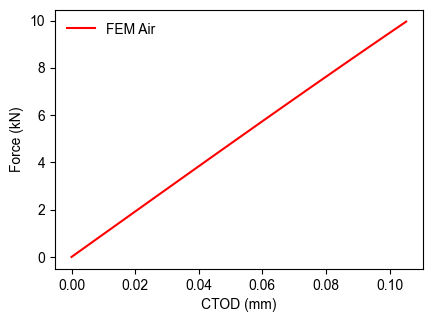

In [ ]:
ax = PlotLine()

ax.plot(disp_y*1e3, force_y*1e-3, "r", label="FEM Air")

ax.set_ylabel("Force (kN)")
ax.set_xlabel("CMOD (mm)")

ax.legend(frameon=False)
# plt.savefig("stress-strain.svg", transparent=True)

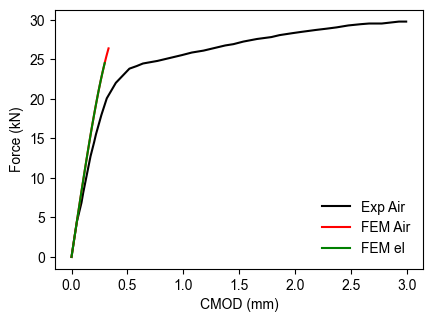

In [ ]:
ax = PlotLine()

ax.plot(data[:,0], data[:,1], "k", label="Exp Air")

ax.plot(disp_y*1e3, force_y*1e-3, "r", label="FEM Air")
ax.plot(disp_y[:50]*1e3, force_y[:50]*1e-3, "g", label="FEM el")

# ax.plot(disp_y[340]/0.03, force_y[340]*1e-6/(np.pi*(0.003)**2), marker="o")

ax.set_ylabel("Force (kN)")
ax.set_xlabel("CMOD (mm)")

ax.legend(frameon=False)
# plt.savefig("stress-strain.svg", transparent=True)

In [149]:
50.8*0.55

27.94

In [166]:
50.8 - 50.8*0.54

23.368

In [203]:
(22.5e-3 - 0.021624)

0.0008759999999999983

In [175]:
steps = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
force_calib3 = np.zeros(len(steps))

In [181]:
with h5py.File("CT_Calib3.mech.out.hdf5", "r") as fh5:
    
    for iStep in range(len(steps)):
        
        force_calib3[iStep] = fh5["Force/Step_"+str(steps[iStep])][()][topY_DOFs].sum()*12.7e-3

In [204]:
da_force = data = np.loadtxt("Calib3.csv", delimiter=",", skiprows=1)

Text(0.5, 0, '$\\Delta a$ (mm)')

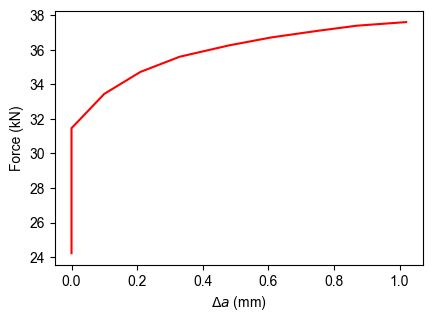

In [206]:
ax = PlotLine()

ax.plot(da_force[:,0]*1e3, da_force[:,1]*1e-3, color="r")

ax.set_ylabel("Force (kN)")
ax.set_xlabel("$\\Delta a$ (mm)")

Text(0.5, 0, '$\\Delta a$ (mm)')

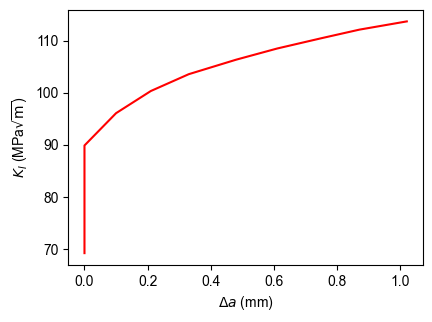

In [230]:
# Dimensions in meters
B = 12.7e-3   
W = 50.8e-3   
a0 = 22.5e-3  

delta_a = da_force[:,0] 
current_a = delta_a + a0
alpha = current_a / W

# Corrected powers: 1, 2, 3, 4
f = ((2 + alpha) / (1 - alpha)**1.5) * (
    0.886 + 
    4.64 * alpha - 
    13.32 * alpha**2 + 
    14.72 * alpha**3 - 
    5.6 * alpha**4
)

# Result in Pa*sqrt(m)
KI_Pa_m = (da_force[:,1] / (B * np.sqrt(W))) * f

# # OPTION A: Plot in MPa*sqrt(mm) -> Values will be ~3000
# KI_plot = KI_Pa_m * 3.1622e-5
# unit_label = "K$_I$ (MPa$\\sqrt{mm}$)"

# OPTION B: Plot in MPa*sqrt(m) -> Values will be ~110 (Recommended for standard papers)
KI_plot = KI_Pa_m / 1e6
unit_label = r"$K_I$ (MPa$\sqrt{\text{m}}$)"

ax = PlotLine()
ax.plot(da_force[:,0]*1e3, KI_plot, color="r")
ax.set_ylabel(unit_label)
ax.set_xlabel("$\\Delta a$ (mm)")

In [283]:
# Young's modulus
Emod = 210e9
# Poisson's ratio
nu = 0.3

J_el = KI_Pa_m**2*(1 - nu**2)/Emod/1000

Cel = force_y[50]/disp_y[50] 

b0 = W - a0
eta = 2.0 + 0.522 * (b0 / W) # Standard ASTM eta for CT specimens

# Let's assume you have your CMOD and Force data
# cmod = displacement in meters
# force = force in Newtons
cmod = disp_y # Use the actual index of your CMOD column
force = force_y

# 1. Initialize the area array
area_total = np.zeros(len(steps))
apl_array = np.zeros(len(steps))

# 2. Loop through your selected steps
for i in range(len(steps)):
    # The actual index in your full data
    idx = steps[i] 
    
    # Calculate total area from 0 up to the current selected index
    # Note: slice is [:idx] to include points up to that index
    area_total[i] = np.trapezoid(force[:idx], cmod[:idx])
    
    # Calculate current elastic triangle using the force at this EXACT index
    # We use idx-1 to stay within array bounds
    current_force = force[idx-1]
    area_elastic_i = 0.5 * (current_force**2) / Cel
    
    # Subtract to find plastic area for this step
    apl_array[i] = max(0, area_total[i] - area_elastic_i)


# 4. CONVERT TO J_pl (kJ/m^2)
# J_pl = (eta * Apl) / (B * b0)
# Dividing by 1000 converts J/m^2 to kJ/m^2
J_pl = (eta * apl_array) / (B * b0) / 1000

J_total = J_pl+J_el

Text(0.5, 0, '$\\Delta a$ (mm)')

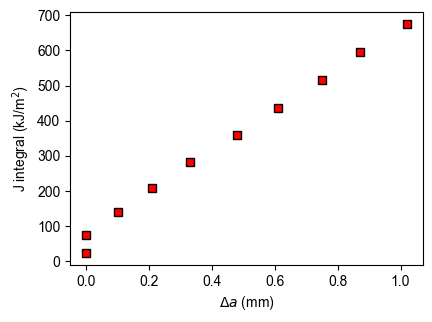

In [284]:
ax = PlotLine()
ax.plot(da_force[:,0]*1e3, J_total, color="r", marker='s', ls='None', mec="k")
ax.set_ylabel("J integral (kJ/m$^2$)")
ax.set_xlabel("$\\Delta a$ (mm)")

In [286]:
da_force

array([[0.00000000e+00, 2.42297753e+04],
       [0.00000000e+00, 3.14651091e+04],
       [1.00000000e-04, 3.34530924e+04],
       [2.10000000e-04, 3.47228559e+04],
       [3.30000000e-04, 3.56039108e+04],
       [4.80000000e-04, 3.62587249e+04],
       [6.10000000e-04, 3.67235175e+04],
       [7.50000000e-04, 3.71010427e+04],
       [8.70000000e-04, 3.74000118e+04],
       [1.02000000e-03, 3.76077141e+04]])

Fit Results: J = 652.52 * (da)^0.754


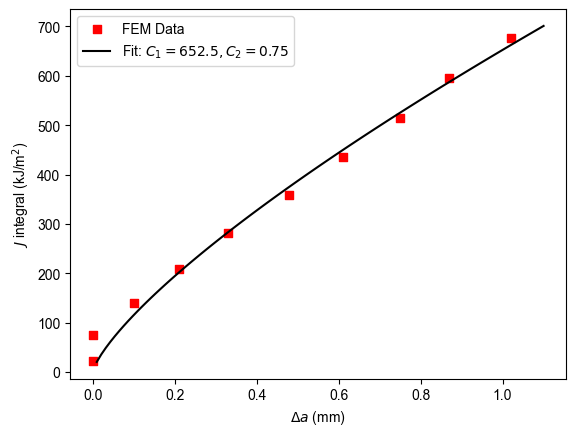

In [287]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Prepare your data (Ensure units are consistent)
# x_data: Delta_a in mm
# y_data: J_total in kJ/m^2
x_data = da_force[:,0] * 1e3  # Convert meters to mm
y_data = J_total  # Already in kJ/m^2 from your previous code

# Note: Exclude the first point if Delta_a is 0 to avoid log(0) errors
mask = x_data > 0
x_fit = x_data[mask]
y_fit = y_data[mask]

# 2. Define the Power Law function
def power_law(da, c1, c2):
    return c1 * (da**c2)

# 3. Perform the fit
# popt contains [C1, C2]
popt, pcov = curve_fit(power_law, x_fit, y_fit)
c1, c2 = popt

print(f"Fit Results: J = {c1:.2f} * (da)^{c2:.3f}")

# 4. Generate the fit line for plotting
da_plot = np.linspace(0.01, 1.1, 100)
j_plot = power_law(da_plot, c1, c2)

# 5. Plotting
plt.scatter(x_data, y_data, color='red', marker='s', label='FEM Data')
plt.plot(da_plot, j_plot, 'k-', label=f'Fit: $C_1={c1:.1f}, C_2={c2:.2f}$')
plt.xlabel(r'$\Delta a$ (mm)')
plt.ylabel(r'$J$ integral (kJ/m$^2$)')
plt.legend()
plt.show()